# 2. házi feladat: Célzott és nem célzott poisoning támadás

## Tartalom
1. **Előkészítés** – Adat betöltés, előfeldolgozás, clean + surrogate modellek
2. **1. feladat** – Untargeted poisoning
3. **2. feladat** – Targeted poisoning


## Előkészítés

### Importok és beállítások

In [31]:
!pip install numpy torch scikit-learn matplotlib pandas
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import json
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


Device: cpu


### Adat betöltés és előfeldolgozás

In [4]:
# Feature nevek betöltése
with open('nslkdd_features.json', 'r') as f:
    features_info = json.load(f)
col_names = [f['name'] for f in features_info]

# Adat betöltése
train_df = pd.read_csv('KDDTrain+.txt', header=None, names=col_names)
test_df  = pd.read_csv('KDDTest+.txt',  header=None, names=col_names)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

# Bináris címkék: normal=0, attack=1
train_df['binary_label'] = (train_df['label'] != 'normal').astype(int)
test_df['binary_label']  = (test_df['label']  != 'normal').astype(int)

print("Train label:", train_df['binary_label'].value_counts().to_dict())
print("Test label:",  test_df['binary_label'].value_counts().to_dict())


Train: (125973, 43), Test: (22544, 43)
Train label: {0: 67343, 1: 58630}
Test label: {1: 12833, 0: 9711}


In [5]:
# One-hot encoding
categorical_cols = ['protocol_type', 'service', 'flag']

# Train + test kombinálása
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols)

train_enc = combined_encoded.iloc[:len(train_df)].copy()
test_enc = combined_encoded.iloc[len(train_df):].copy().reset_index(drop=True)

# Feature és label szétválasztása
drop_cols = ['label', 'difficulty', 'binary_label']
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

X_train_full = train_enc[feature_cols].values.astype(np.float32)
y_train_full = train_enc['binary_label'].values.astype(np.float32)
X_test_all = test_enc[feature_cols].values.astype(np.float32)
y_test_all = test_enc['binary_label'].values.astype(np.float32)

input_dim = X_train_full.shape[1]
print(f"Feature szám: {input_dim}")


Feature szám: 122


In [6]:
# StandardScaler alkalmazása
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full).astype(np.float32)
X_test_all = scaler.transform(X_test_all).astype(np.float32)

# Train - Validation felosztás, 80%-20% arányban
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

# Feature határok - WiB-hez
feat_min = X_train.min(axis=0)
feat_max = X_train.max(axis=0)

print(f"Train: {X_train.shape} (normal={int((y_train==0).sum())}, attack={int((y_train==1).sum())})")
print(f"Validation:   {X_val.shape} (normal={int((y_val==0).sum())}, attack={int((y_val==1).sum())})")
print(f"Test:  {X_test_all.shape} (normal={int((y_test_all==0).sum())}, attack={int((y_test_all==1).sum())})")


Train: (100778, 122) (normal=53874, attack=46904)
Validation:   (25195, 122) (normal=13469, attack=11726)
Test:  (22544, 122) (normal=9711, attack=12833)


### Modell architektúra és segédfüggvények

In [7]:
from IDS import IntrusionDetector

# Saját train függvényt készítettem, mivel az IDS-py-ban lévő  train_model() fv.
# test adatot is kér és minden epoch-ban printeli az eredményeket
# Ez poisoningnál, a sok újratanításnál rengeteg output lenne
# A hiperparaméterek változatlanok:
# Adam optimizer, lr=0.001, batch_size=128, 10 epoch, BCEWithLogitsLoss
def train_ids(X_tr, y_tr, epochs=10, batch_size=128, lr=0.001, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    X_t = torch.FloatTensor(X_tr).to(device)
    y_t = torch.FloatTensor(y_tr).unsqueeze(1).to(device)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model = IntrusionDetector(X_tr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

    return model

#2 segédfüggvény
def predict(model, X):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.FloatTensor(X).to(device)))
        return (probs > 0.5).float().cpu().numpy().flatten()

def get_accuracy(model, X, y):
    return accuracy_score(y, predict(model, X))

### Clean modell és 5 surrogate modell tanítása

In [8]:
# Clean modell tanítása
print("Clean modell tanítása")
clean_model = train_ids(X_train, y_train, seed=SEED)
clean_train_acc = get_accuracy(clean_model, X_train, y_train)
clean_val_acc = get_accuracy(clean_model, X_val, y_val)
print(f"Clean modell - Train accuracy: {clean_train_acc:.4f}, Val acc: {clean_val_acc:.4f}")

# 5 surrogate modell a tesztadaton
print("\n5 surrogate modell tanítása")
surrogates = []
for i in range(5):
    s = train_ids(X_test_all, y_test_all, seed=i * 1000 + 42)
    s_acc = get_accuracy(s, X_test_all, y_test_all)
    print(f"  Surrogate {i+1}: test accuracy = {s_acc:.4f}")
    surrogates.append(s)

Clean modell tanítása
Clean modell - Train accuracy: 0.9961, Val acc: 0.9948

5 surrogate modell tanítása
  Surrogate 1: test accuracy = 0.9766
  Surrogate 2: test accuracy = 0.9755
  Surrogate 3: test accuracy = 0.9764
  Surrogate 4: test accuracy = 0.9755
  Surrogate 5: test accuracy = 0.9756


---
## 1. feladat: Untargeted Poisoning

### Task 1: Véletlenszerű kiválasztás

In [9]:
p_values = [30, 50, 70]
q1_results = {p: [] for p in p_values}

for p in p_values:
    for trial in range(5):
        seed_t = trial * 111 + p
        np.random.seed(seed_t)

        # p% véletlenszerűen kiválasztott minta, invertált címkével hozzáadva
        n_poison = int(len(y_train) * p / 100)
        idx = np.random.choice(len(y_train), size=n_poison, replace=False)

        X_poisoned = np.concatenate([X_train, X_train[idx]])
        y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])

        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q1_results[p].append(val_a)

    print(f"  p={p}%: mean={np.mean(q1_results[p]):.4f} ± {np.std(q1_results[p]):.4f}")
    print(f"         values={[f'{v:.4f}' for v in q1_results[p]]}")


  p=30%: mean=0.9904 ± 0.0008
         values=['0.9916', '0.9905', '0.9905', '0.9903', '0.9892']
  p=50%: mean=0.9884 ± 0.0006
         values=['0.9873', '0.9885', '0.9890', '0.9884', '0.9889']
  p=70%: mean=0.9829 ± 0.0034
         values=['0.9818', '0.9771', '0.9830', '0.9867', '0.9861']


### Task 2: Loss-alapú kiválasztás

In [10]:
# Minden train mintára kiszámoljuk az átlagos loss-t, invertált címkével az 5 surrogate-en
criterion_none = nn.BCEWithLogitsLoss(reduction='none')
X_t_tr = torch.FloatTensor(X_train).to(device)
y_inv = torch.FloatTensor(1.0 - y_train).unsqueeze(1).to(device)

all_losses = []
for sm in surrogates:
    sm.eval()
    with torch.no_grad():
        out = sm(X_t_tr)
        l = criterion_none(out, y_inv).cpu().numpy().flatten()
        all_losses.append(l)

avg_inv_loss = np.mean(all_losses, axis=0)
print(f"Inverted loss statisztikák: mean={avg_inv_loss.mean():.4f}, "
      f"min={avg_inv_loss.min():.4f}, max={avg_inv_loss.max():.4f}")


Inverted loss statisztikák: mean=11.9018, min=0.0000, max=622.1893


In [11]:
q2_results = {p: [] for p in p_values}

for p in p_values:
    # Legnagyobb átlagos invertált loss-ú minták felső p%-a
    n_poison = int(len(y_train) * p / 100)
    idx = np.argsort(avg_inv_loss)[-n_poison:]

    X_poisoned = np.concatenate([X_train, X_train[idx]])
    y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])

    for trial in range(5):
        seed_t = trial * 222 + p
        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q2_results[p].append(val_a)

    print(f"  p={p}%: mean={np.mean(q2_results[p]):.4f} ± {np.std(q2_results[p]):.4f}")
    print(f"         values={[f'{v:.4f}' for v in q2_results[p]]}")


  p=30%: mean=0.9835 ± 0.0012
         values=['0.9823', '0.9826', '0.9849', '0.9850', '0.9825']
  p=50%: mean=0.8292 ± 0.0784
         values=['0.8538', '0.8688', '0.8726', '0.8776', '0.6731']
  p=70%: mean=0.6857 ± 0.0348
         values=['0.6973', '0.7146', '0.6917', '0.7070', '0.6180']


### Box plot összehasonlítás

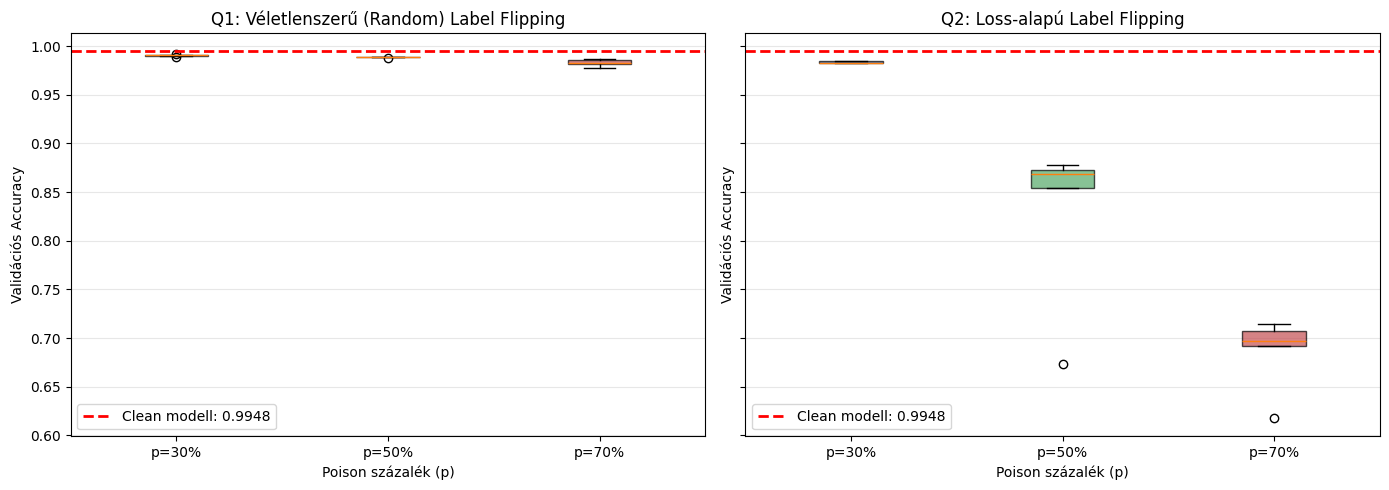

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, data, title in [
    (axes[0], q1_results, 'Q1: Véletlenszerű (Random) Label Flipping'),
    (axes[1], q2_results, 'Q2: Loss-alapú Label Flipping')
]:
    bp = ax.boxplot([data[p] for p in p_values],
                    labels=[f'p={p}%' for p in p_values], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(clean_val_acc, color='red', ls='--', lw=2,
               label=f'Clean modell: {clean_val_acc:.4f}')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Validációs Accuracy')
    ax.set_xlabel('Poison százalék (p)')
    ax.legend(loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_task1.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 3: Hasonlítsa össze a fenti két esetben kapott eredményeket! Melyik hatékonyabb és miért?

A loss-based módszer egyértelműen hatékonyabb. A random kiválasztásnál még p=70%-nál is csak 0.9829-re csökken a validációs accuracy (a clean 0.9948-ról), ami alig észrevehető romlás. Ezzel szemben a loss-based módszer p=50%-nál már 0.8292-re rontja, p=70%-nál pedig 0.6857-re – ez már közel használhatatlan modell.

Az ok az, hogy a loss-based módszer a surrogate modelleken számolt invertált loss alapján célzottan azokat a mintákat választja ki, amelyek a döntési határ közelében vannak; ezek átcímkézése a legnagyobb zavart okozza a tanítás során. A random kiválasztás viszont rengeteg "egyértelmű" mintát is átcímkéz (pl. nyilvánvaló DoS támadásokat), amiknek az invertálása nem zavaró, mert a modell könnyen felismeri hogy nem illenek a másik osztályba.

Érdemes azt is megjegyezni, hogy a loss-based módszernél a szórás is nagyobb (p=50%-nál 0.6731–0.8776 közötti értékek), ami azt mutatja, hogy a random inicializálás erősen befolyásolja, hogy mennyire hat a mérgezett adat a modell döntési határára.


### Task 4: Elemezze a támadások megvalósíthatóságát a gyakorlatban! Javasoljon bármilyen védekezést amivel a támadás sikeressége csökkenthető (nem kell implementálni)!

A támadás **megvalósíthatósága** a gyakorlatban korlátozott, mert feltételezi, hogy:
- a támadó hozzáfér a teljes tanítóadathoz
- képes mintákat hozzáadni anélkül hogy bárki észrevenné
- és a loss-based változatnál ismeri a modell architektúráját is surrogate tanításhoz

Mindhárom feltétel együttes teljesülése ritka, de nem lehetetlen, például crowdsourced adatgyűjtésnél, nyílt threat intelligence feed-eknél, vagy ha a támadó közvetlenül a hálózati forgalmat manipulálja amiből az IDS tanul.

**Védekezési lehetőségek**:

A tanítóadaton futtatott anomália-detekció vagy outlier szűrés kiszűrheti a gyanúsan átcímkézett mintákat (pl. egy egyértelmű DoS forgalom ami "normal" címkével van ellátva).

Cross-validation alapú szűrés: ha egy minta több fold-ban is konzisztensen rosszul klasszifikálódik, valószínűleg hibás a címkéje.

DP-SGD (differenciálisan privát tanítás): a gradient clipping és a zajhozzáadás csökkenti az egyes minták hatását, így a poison minták kevésbé tudják eltolni a modellt.

Egyszerű heurisztika: ha a tanítóadat mérete hirtelen megnő, az már gyanús lehet.

---
## 2. feladat: Targeted Poisoning


### Target minták kiválasztása

In [15]:
clean_model.eval()
clean_preds = predict(clean_model, X_test_all)

# Feltételek: attack (y=1), clean modell helyesen klasszifikálja
attack_correct_mask = (y_test_all == 1) & (clean_preds == 1)
candidate_idx = np.where(attack_correct_mask)[0]
print(f"Helyesen klasszifikált attack minták a tesztben: {len(candidate_idx)}")

# Loss y_adv=0 (normal) címkére → minimálisat keressük (bizonytalan minták)
with torch.no_grad():
    X_cand_t = torch.FloatTensor(X_test_all[candidate_idx]).to(device)
    y_adv_cand = torch.zeros(len(candidate_idx), 1).to(device)
    out_cand = clean_model(X_cand_t)
    loss_on_normal = nn.BCEWithLogitsLoss(reduction='none')(out_cand, y_adv_cand)
    loss_on_normal = loss_on_normal.cpu().numpy().flatten()

# Top 10 legkisebb loss → leginkább bizonytalan
top10 = np.argsort(loss_on_normal)[:10]
target_indices = candidate_idx[top10]

print(f"\nKiválasztott 10 target index: {target_indices}")
print(f"Loss értékek y_adv=0 címkére: {np.round(loss_on_normal[top10], 4)}")
print(f"Eredeti címkék: {y_test_all[target_indices]}")

X_targets = X_test_all[target_indices]
y_targets = y_test_all[target_indices]
y_adv = 0.0  # Célcímke: normal


Helyesen klasszifikált attack minták a tesztben: 8987

Kiválasztott 10 target index: [10863   994 21173  8660 19648 13631 11777  5016 14090  2696]
Loss értékek y_adv=0 címkére: [0.6962 0.6975 0.6987 0.6993 0.7007 0.7013 0.7037 0.7076 0.7081 0.7148]
Eredeti címkék: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Segédfüggvények a gradiens számításhoz

In [16]:
# Gradiens számítás a loss-ból a modell paramétereire nézve
# create_graph=True kell a WiB-hez, hogy a delta-k is kapjanak gradienst
def get_param_grad(model, x, y_label, create_graph=False):
    model.eval()
    for param in model.parameters():
        param.requires_grad_(True)

    x_in = x.unsqueeze(0) if x.dim() == 1 else x
    if not create_graph:
        x_in = x_in.detach()
    x_in = x_in.to(next(model.parameters()).device)
    y_in = torch.tensor([[float(y_label)]], dtype=torch.float32, device=x_in.device)

    output = model(x_in)
    loss = nn.BCEWithLogitsLoss()(output, y_in)

    params = [p for p in model.parameters() if p.requires_grad]
    grads = torch.autograd.grad(loss, params, create_graph=create_graph)
    return torch.cat([g.flatten() for g in grads])

### Base minták kiválasztása

In [24]:
# Base minták kiválasztása a teszthalmazból
# Csak y_adv_t címkéjű mintákból, gradiens koszinusz hasonlóság alapján (5 surrogate átlaga)
def select_base_samples(target_x, y_adv_t, X_test, y_test, surrogates, p_count):
    cand_mask = (y_test == y_adv_t)
    cand_idx = np.where(cand_mask)[0]
    print(f"Candidate base minták száma (y={y_adv_t}): {len(cand_idx)}")

    # Target gradiensek előszámítása minden surrogate-re, fixed
    target_grads = []
    x_t = torch.FloatTensor(target_x).to(device)
    for model in surrogates:
        g = get_param_grad(model, x_t, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    # Koszinusz hasonlóság minden candidate-re (5 modell átlaga)
    avg_sims = np.zeros(len(cand_idx))
    for bi in range(len(cand_idx)):
        ci = cand_idx[bi]
        x_c = torch.FloatTensor(X_test[ci]).to(device)
        sims = []
        for j, model in enumerate(surrogates):
            g_c = get_param_grad(model, x_c, y_test[ci], create_graph=False)
            for param in model.parameters():
                param.requires_grad_(False)
            sim = F.cosine_similarity(
                target_grads[j].unsqueeze(0), g_c.unsqueeze(0)
            ).item()
            sims.append(sim)
        avg_sims[bi] = np.mean(sims)
        if (bi + 1) % 1000 == 0:
            print(f"Progress: {bi+1}/{len(cand_idx)}")

    top_p_idx = np.argsort(avg_sims)[-p_count:][::-1]
    selected = cand_idx[top_p_idx]
    sims_selected = avg_sims[top_p_idx]
    print(f"Kiválasztott {p_count} base minta, "
          f"cos sim: [{sims_selected[-1]:.4f}, {sims_selected[0]:.4f}]")
    return selected

### Witches' Brew PGD támadás

In [25]:
# Witches' Brew poison crafting PGD optimalizációval
# create_graph=True kell, hogy a delta-k is kapjanak gradienst
def witches_brew_attack(target_x, y_adv_t, base_indices, X_test, y_test,
                         surrogates, feat_min_np, feat_max_np, max_iter=1000):
    p = len(base_indices)
    fmin = torch.FloatTensor(feat_min_np).to(device)
    fmax = torch.FloatTensor(feat_max_np).to(device)

    # Target gradiensek előszámítása
    x_target = torch.FloatTensor(target_x).to(device)
    target_grads = []
    for model in surrogates:
        g = get_param_grad(model, x_target, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    # Base tensorok és delta-k inicializálása
    base_tensors = []
    base_labels = []
    deltas = []
    for i in range(p):
        bx = torch.FloatTensor(X_test[base_indices[i]]).to(device).detach()
        base_tensors.append(bx)
        base_labels.append(float(y_test[base_indices[i]]))
        delta = torch.zeros_like(bx, requires_grad=True)
        deltas.append(delta)

    optimizer = torch.optim.SGD(deltas, lr=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=75, eps=1e-06
    )

    best_loss = float('inf')
    best_deltas = [d.data.clone() for d in deltas]

    for it in range(max_iter):
        optimizer.zero_grad()

        total_loss = torch.zeros(1, device=device)[0]

        for j, model in enumerate(surrogates):
            model.eval()
            for param in model.parameters():
                param.requires_grad_(True)

            for i in range(p):
                # Poison minta: base + delta, clamp-elve a feature határokra
                poison_x = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)

                # Gradiens a modell paramétereire nézve
                g_poison = get_param_grad(
                    model, poison_x, base_labels[i], create_graph=True
                )

                cos_sim = F.cosine_similarity(
                    target_grads[j].unsqueeze(0),
                    g_poison.unsqueeze(0)
                )
                total_loss = total_loss + (1.0 - cos_sim.squeeze())

        total_loss = total_loss / 5.0
        total_loss.backward()

        optimizer.step()
        scheduler.step(total_loss.item())

        # Modell paraméterek gradiensének nullázása és kikapcsolása
        for model in surrogates:
            model.zero_grad()
            for param in model.parameters():
                param.requires_grad_(False)

        # Delta clamp: base+delta a [feat_min, feat_max] tartományban maradjon
        with torch.no_grad():
            for i in range(p):
                clamped = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)
                deltas[i].data = clamped - base_tensors[i]

        loss_val = total_loss.item()
        if loss_val < best_loss:
            best_loss = loss_val
            best_deltas = [d.data.clone() for d in deltas]

        if it % 200 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Iter {it}/{max_iter}: loss={loss_val:.6f}, lr={lr_now:.6f}")

    print(f"Best loss: {best_loss:.6f}")

    # Poison minták összeállítása
    poison_X = []
    poison_y = []
    for i in range(p):
        px = torch.clamp(base_tensors[i] + best_deltas[i], fmin, fmax)
        poison_X.append(px.cpu().numpy())
        poison_y.append(base_labels[i])
    return np.array(poison_X, dtype=np.float32), np.array(poison_y, dtype=np.float32)

### Támadás végrehajtása

In [26]:
targeted_results = {}

# Előszámítás: base minták minden target-re egyszer
# p=5 esetén az első 5 legjobbat használjuk
print("Base minták számítása minden target-re")
all_base_idx = {}
for t_pos, t_idx in enumerate(target_indices):
    print("\nTarget " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ") base kiválasztás...")
    base_idx_15 = select_base_samples(
        X_test_all[t_idx], y_adv, X_test_all, y_test_all, surrogates, p_count=15
    )
    all_base_idx[t_idx] = base_idx_15

for p_base in [5, 15]:
    print()
    print("=" * 70)
    print("TARGETED POISONING: p = " + str(p_base) + " base minta target-enként")
    print("=" * 70)

    successes = 0

    for t_pos, t_idx in enumerate(target_indices):
        print("\nTarget " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ")")

        base_idx = all_base_idx[t_idx][:p_base]

        print("WiB PGD (1000 iter, p=" + str(p_base) + ")")
        poison_X, poison_y = witches_brew_attack(
            X_test_all[t_idx], y_adv, base_idx,
            X_test_all, y_test_all, surrogates,
            feat_min, feat_max, max_iter=1000
        )

        # Újratanítás szennyezett adaton + kiértékelés
        X_poisoned = np.concatenate([X_train, poison_X])
        y_poisoned = np.concatenate([y_train, poison_y])

        retrained = train_ids(X_poisoned, y_poisoned, seed=int(t_idx) + 9999)
        pred = predict(retrained, X_test_all[t_idx:t_idx+1])

        is_success = (pred[0] == y_adv)
        if is_success:
            successes += 1

        result_str = "SIKERES" if is_success else "SIKERTELEN"
        print("Predikció: " + str(int(pred[0])) + ", Cél (y_adv): " + str(int(y_adv)) + " -> " + result_str)

    attack_rate = successes / 10
    targeted_results[p_base] = {'successes': successes, 'rate': attack_rate}
    print("\nTámadás sikeressége p=" + str(p_base) + ": " + str(successes) + "/10 = " + f"{attack_rate:.0%}")

Base minták számítása minden target-re

Target 1/10 (test index=10863) base kiválasztás...
Candidate base minták száma (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos sim: [0.4437, 0.8274]

Target 2/10 (test index=994) base kiválasztás...
Candidate base minták száma (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos sim: [0.4436, 0.8274]

Target 3/10 (test index=21173) base kiválasztás...
Candidate base minták száma (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos s

### 2.6 Eredmények összefoglalása

ÖSSZEFOGLALÓ

Clean modell validációs accuracy: 0.9948

1. feladat: Untargeted Poisoning
Módszer                        p=30%      p=50%      p=70%
-------------------------------------------------------
Random                        0.9904     0.9884     0.9829
Loss-based                    0.9835     0.8292     0.6857

2. feladat: Targeted Poisoning (WiB)
  p=5: 8/10 sikeresen félreklasszifikálva (80%)
  p=15: 10/10 sikeresen félreklasszifikálva (100%)


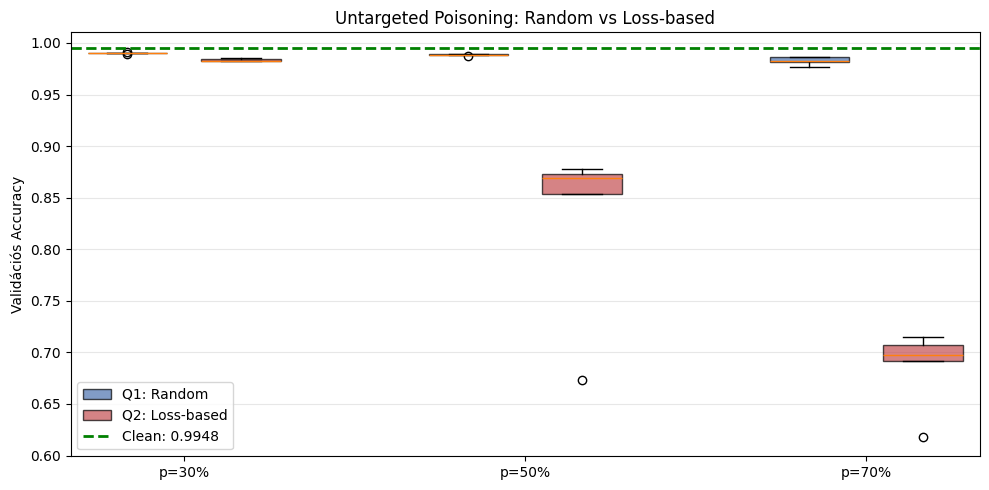

In [29]:
print("ÖSSZEFOGLALÓ")

print(f"\nClean modell validációs accuracy: {clean_val_acc:.4f}")

print(f"\n1. feladat: Untargeted Poisoning")
print(f"{'Módszer':<25} {'p=30%':>10} {'p=50%':>10} {'p=70%':>10}")
print("-" * 55)
print(f"{'Random':<25} "
      f"{np.mean(q1_results[30]):>10.4f} "
      f"{np.mean(q1_results[50]):>10.4f} "
      f"{np.mean(q1_results[70]):>10.4f}")
print(f"{'Loss-based':<25} "
      f"{np.mean(q2_results[30]):>10.4f} "
      f"{np.mean(q2_results[50]):>10.4f} "
      f"{np.mean(q2_results[70]):>10.4f}")

print(f"\n2. feladat: Targeted Poisoning (WiB)")
for p_b, res in targeted_results.items():
    print(f"  p={p_b}: {res['successes']}/10 sikeresen félreklasszifikálva ({res['rate']:.0%})")

# Combined box plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
positions_q1 = [1, 4, 7]
positions_q2 = [2, 5, 8]

bp1 = ax.boxplot([q1_results[p] for p in p_values], positions=positions_q1,
                  patch_artist=True, widths=0.7)
bp2 = ax.boxplot([q2_results[p] for p in p_values], positions=positions_q2,
                  patch_artist=True, widths=0.7)

for patch in bp1['boxes']:
    patch.set_facecolor('#4C72B0'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#C44E52'); patch.set_alpha(0.7)

ax.axhline(clean_val_acc, color='green', ls='--', lw=2, label=f'Clean: {clean_val_acc:.4f}')
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(['p=30%', 'p=50%', 'p=70%'])
ax.set_ylabel('Validációs Accuracy')
ax.set_title('Untargeted Poisoning: Random vs Loss-based')
ax.legend([bp1['boxes'][0], bp2['boxes'][0], ax.lines[-1]],
          ['Q1: Random', 'Q2: Loss-based', f'Clean: {clean_val_acc:.4f}'],
          loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('combined_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 2. feladat Q2: Gyakorlati elemzés és védekezés

**Megvalósíthatóság**:

A Witches' Brew támadás az untargeted-nél jóval erősebb feltételezésekkel él. A támadónak ismernie kell a modell architektúráját és hiperparamétereit, hozzá kell férnie a teljes teszt- és tanítóadathoz, képesnek kell lennie surrogate modelleket tanítani a tesztadaton és mintákat kell tudnia hozzáadni a tanítóadathoz. Emellett a támadás számításigényes is, target-enként 1000 PGD iteráció 5 surrogate modell second-order gradienseivel.

A gyakorlatban ez a feltételrendszer ritkán áll fenn, de federated learning vagy közös adatmegosztásos környezetekben elképzelhető.

Az eredmények azt mutatják, hogy a támadás hatékonysága erősen függ a base minták minőségétől: ahol a koszinusz hasonlóság alacsony volt (target 5, 9), ott p=5-tel nem sikerült a támadás. Ez azt jelenti, hogy ha a támadónak kevesebb hasonló mintája van, a támadás megbukhat.

**Védekezési lehetőségek**:

- Spectral signatures: a poison minták jellemzően hasonló irányba tolják el a belső reprezentációkat, ami PCA-val detektálható a tanítóadaton.

- Több random inicializálással tanított modell (ensemble) aggregálása, a WiB támadás egy konkrét tanítási trajektóriát céloz, ensemble ellen kevésbé hatékony.

- DP-SGD: a gradient clipping és zajhozzáadás csökkenti, hogy néhány poison minta dominálhassa a tanulást.

- A tanítóadat növekedésének monitorozása és az új minták statisztikai ellenőrzése a meglévő eloszláshoz képest.